# Notebook to Assess SH24 Natural Seeing Control Loop

Preamble

In [2]:
import numpy as np
import pandas as pd

from scipy import sparse
import scipy.linalg as la
# from scipy.linalg import block_diag
# import scipy.io as spio

import os
from os import path

from pathlib import Path

import matplotlib.pyplot as plt

Load simulation results

In [45]:
df = pd.read_parquet("/home/rromano/Workspace/gr-ns-im/web_server/static/qp/sh24_48_act-dyn/s-int_ki0p5_m2s1rbm_data_5.parquet")
m2rbm_s_int = np.vstack(df["M2RBM<1>"])
df = pd.read_parquet("/home/rromano/Workspace/gr-ns-im/web_server/static/qp/sh24_48_act-dyn/double-int_m2s1rbm_data_5.parquet")
# df = pd.read_parquet("/home/rromano/Workspace/gr-ns-im/web_server/static/qp/sh24_48_act-dyn/agws_sh24_data_5.parquet")
m2rbm_d_int = np.vstack(df["M2RBM<1>"])

Plot M2 RBM SH24 loop

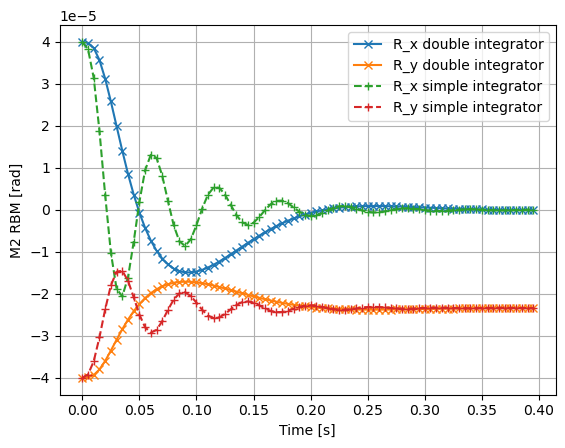

In [46]:
t = 5e-3 * np.arange(m2rbm_s_int.shape[0])
plt.plot(t, m2rbm_d_int[:, 3], 'x-', label="R_x double integrator")
plt.plot(t, m2rbm_d_int[:, 4], 'x-', label="R_y double integrator")
plt.plot(t, m2rbm_s_int[:, 3], '+--', label="R_x simple integrator")
plt.plot(t, m2rbm_s_int[:, 4], '+--', label="R_y simple integrator")
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("M2 RBM [rad]")
#plt.xlim(0, t[10])
plt.show()

In [40]:
df = pd.read_parquet("/home/rromano/Workspace/gr-ns-im/web_server/static/qp/sh24_48_act-dyn/optical_state.parquet")
df#
m2rbm_d_int = np.vstack(df["M2RigidBodyMotions"])
m1shape_d_int = np.vstack(df["M1ModeShapes"])

Plot M2 RBM SH24 and SH48 loops

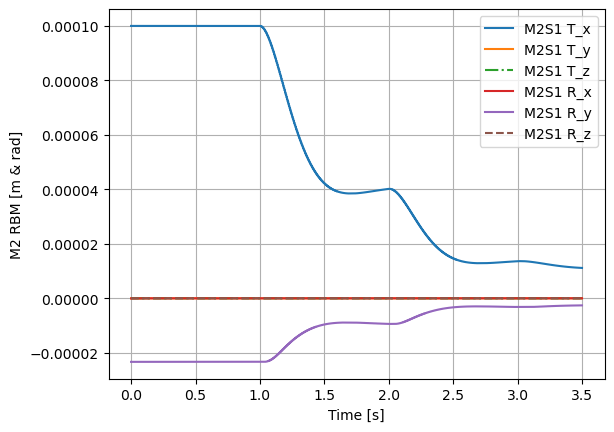

In [44]:
t = 1e-3 * np.arange(m2rbm_d_int.shape[0])
plt.plot(t, m2rbm_d_int[:, 0], '-', label="M2S1 T_x")
plt.plot(t, m2rbm_d_int[:, 1], '-', label="M2S1 T_y")
plt.plot(t, m2rbm_d_int[:, 2], '-.', label="M2S1 T_z")
plt.plot(t, m2rbm_d_int[:, 3], '-', label="M2S1 R_x")
plt.plot(t, m2rbm_d_int[:, 4], '-', label="M2S1 R_y")
plt.plot(t, m2rbm_d_int[:, 5], '--', label="M2S1 R_z")
# plt.plot(t, m2rbm_s_int[:, 3], '+--', label="R_x simple integrator")
# plt.plot(t, m2rbm_s_int[:, 4], '+--', label="R_y simple integrator")
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("M2 RBM [m & rad]")
#plt.xlim(0, t[10])
plt.show()